# Tech Layoffs Analysis — Data Cleaning Challenge (Week 5)

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('layoffs.csv')

In [4]:
df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Thinkific,"Vancouver, Non-U.S.",96.0,9/23/2026,NaN,Education,https://investors.thinkific.com/2026-09-23-Thi...,Post-IPO,22.0,Canada,9/24/2026
1,Intel,Sacramento,52.0,9/23/2026,NaN,Hardware,https://www.kron4.com/news/technology-ai/intel...,Post-IPO,12.0,United States,9/23/2026
2,Microsoft,Seattle,500.0,9/22/2026,NaN,Other,https://www.businessinsider.com/microsoft-star...,Post-IPO,1.0,United States,9/23/2026
3,Expedia,Seattle,58.0,9/22/2026,NaN,Travel,https://www.geekwire.com/2026/expedia-group-la...,Post-IPO,3300.0,United States,9/26/2026
4,Apple,SF Bay Area,NaN,9/21/2026,NaN,Hardware,https://www.bloomberg.com/news/newsletters/202...,Post-IPO,1200.0,United States,9/22/2026


In [5]:
df.columns.to_list()

['company',
 'location',
 'total_laid_off',
 'date',
 'percentage_laid_off',
 'industry',
 'source',
 'stage',
 'funds_raised',
 'country',
 'date_added']

In [6]:
df.isnull().sum()

company                   0
location                  1
total_laid_off         1600
date                      0
percentage_laid_off    1728
industry                  2
source                    3
stage                     8
funds_raised            550
country                   2
date_added                0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4615 entries, 0 to 4614
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              4615 non-null   object 
 1   location             4614 non-null   object 
 2   total_laid_off       3015 non-null   float64
 3   date                 4615 non-null   object 
 4   percentage_laid_off  2887 non-null   float64
 5   industry             4613 non-null   object 
 6   source               4612 non-null   object 
 7   stage                4607 non-null   object 
 8   funds_raised         4065 non-null   float64
 9   country              4613 non-null   object 
 10  date_added           4615 non-null   object 
dtypes: float64(3), object(8)
memory usage: 396.7+ KB


In [8]:
df.describe()

,total_laid_off,percentage_laid_off,funds_raised
count,3015.000000,2887.000000,4065.000000
mean,309.542952,0.296047,910.093258
std,1111.357832,0.306916,4924.342091
min,3.000000,0.000000,0.700000
25%,40.000000,0.100000,55.000000
50%,90.000000,0.170000,176.000000
75%,200.000000,0.330000,485.000000
max,22000.000000,1.000000,121900.000000


In [9]:
df[df.select_dtypes(include='object').columns] = df.select_dtypes(include='object').apply(lambda col: col.str.lower().str.strip())

In [10]:
df['source'].isna().sum()

np.int64(3)

The source column contains 3 missing values, which were retained because the original source information is unavailable.

In [11]:
(df["source"].str.strip() == "").sum()

np.int64(0)

In [12]:
#Handling Datetime
df['date'] = pd.to_datetime(df['date'])
df['date_added'] = pd.to_datetime(df['date_added'])

In [13]:
df[['date','date_added']].dtypes

date          datetime64[ns]
date_added    datetime64[ns]
dtype: object

In [14]:
# Handling missing values

In [15]:
#Categorical Columns
df[['location', 'industry', 'country', 'stage']] = df[['location','industry','country','stage']].fillna('Unknown')

In [16]:
#Numerical Columns
df = df.dropna(subset=['total_laid_off', 'percentage_laid_off'], how='all')
df['funds_raised'] = df['funds_raised'].fillna(df['funds_raised'].median())


In [17]:
df.isnull().sum()

company                  0
location                 0
total_laid_off         852
date                     0
percentage_laid_off    980
industry                 0
source                   0
stage                    0
funds_raised             0
country                  0
date_added               0
dtype: int64

In [18]:
#Checking unusable rows
df[(df['percentage_laid_off'] == 1.0) & 
   (df['total_laid_off'] < 100) &
   (df['total_laid_off'] != 90)][
   ['company', 'total_laid_off', 'percentage_laid_off']
].head(20)

,company,total_laid_off,percentage_laid_off
75,golemon,33.0,1.0
381,bharatagri,37.0,1.0
502,retrain.ai,20.0,1.0
534,noogata,10.0,1.0
562,smashing,7.0,1.0
671,pandion,63.0,1.0
888,humble games,36.0,1.0
896,on,60.0,1.0
1001,arkane studios,96.0,1.0
1054,trendsales,79.0,1.0


In [19]:
df[(df['total_laid_off'] >= 1000) & 
   (df['percentage_laid_off'] <= 0.20)][
   ['company', 'total_laid_off', 'percentage_laid_off']
].sort_values('total_laid_off', ascending=False).head(10)

,company,total_laid_off,percentage_laid_off
558,intel,22000.0,0.20
132,oracle,21000.0,0.13
876,intel,15000.0,0.15
395,amazon,14000.0,0.01
1043,tesla,14000.0,0.10
2515,google,12000.0,0.06
271,dell,11000.0,0.10
3000,meta,11000.0,0.13
2548,microsoft,10000.0,0.05
2932,amazon,10000.0,0.03


In [20]:
# Checking values are broken or not

In [21]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Rows before: {before}, Rows after: {after}, Duplicates removed: {before - after}")

Rows before: 3867, Rows after: 3867, Duplicates removed: 0


In [22]:
print(df[(df['percentage_laid_off']<0) | (df['percentage_laid_off']>1)])

Empty DataFrame
Columns: [company, location, total_laid_off, date, percentage_laid_off, industry, source, stage, funds_raised, country, date_added]
Index: []


In [23]:
print(df[df['total_laid_off'] <= 0])

Empty DataFrame
Columns: [company, location, total_laid_off, date, percentage_laid_off, industry, source, stage, funds_raised, country, date_added]
Index: []


In [24]:
print(df[df['funds_raised'] < 0 ])

Empty DataFrame
Columns: [company, location, total_laid_off, date, percentage_laid_off, industry, source, stage, funds_raised, country, date_added]
Index: []


In [25]:
print(df[df['date'] > pd.Timestamp.today()])

Empty DataFrame
Columns: [company, location, total_laid_off, date, percentage_laid_off, industry, source, stage, funds_raised, country, date_added]
Index: []


In [26]:
df['stage'].value_counts()

stage
post-ipo          965
unknown           625
series b          415
series c          375
acquired          323
series d          319
series a          232
series e          183
seed              143
series f          111
private equity     65
series h           33
subsidiary         27
series g           26
series j           11
series i            8
Unknown             6
Name: count, dtype: int64

In [27]:
df['location'].value_counts().head(20)

location
sf bay area            973
new york city          384
bengaluru, non-u.s.    191
boston                 158
seattle                153
tel aviv, non-u.s.     145
los angeles            138
london, non-u.s.       113
berlin, non-u.s.        86
toronto, non-u.s.       75
sao paulo, non-u.s.     65
austin                  59
chicago                 49
sydney, non-u.s.        46
singapore, non-u.s.     42
mumbai, non-u.s.        40
gurugram, non-u.s.      38
stockholm, non-u.s.     36
san diego               36
lagos, non-u.s.         31
Name: count, dtype: int64

In [28]:
df['country'].value_counts().head(30)

country
united states           2389
india                    335
canada                   160
israel                   160
united kingdom           125
germany                  119
brazil                    82
australia                 77
singapore                 44
sweden                    40
nigeria                   34
indonesia                 31
netherlands               27
china                     21
france                    18
ireland                   14
kenya                     14
estonia                   11
norway                     9
spain                      9
denmark                    9
new zealand                8
austria                    8
poland                     8
switzerland                8
mexico                     8
japan                      6
united arab emirates       6
chile                      6
finland                    5
Name: count, dtype: int64

In [29]:
df['industry'].value_counts().head(30)

industry
finance           469
retail            306
healthcare        293
other             261
consumer          257
transportation    243
food              224
marketing         186
crypto            157
security          139
education         139
media             139
real estate       131
data              117
hr                 96
travel             92
sales              70
hardware           68
logistics          65
infrastructure     61
product            52
recruiting         50
support            49
energy             42
fitness            41
manufacturing      29
ai                 29
legal              20
aerospace          20
construction       20
Name: count, dtype: int64

In [30]:
df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,thinkific,"vancouver, non-u.s.",96.0,2026-09-23,NaN,education,https://investors.thinkific.com/2026-09-23-thi...,post-ipo,22.0,canada,2026-09-24
1,intel,sacramento,52.0,2026-09-23,NaN,hardware,https://www.kron4.com/news/technology-ai/intel...,post-ipo,12.0,united states,2026-09-23
2,microsoft,seattle,500.0,2026-09-22,NaN,other,https://www.businessinsider.com/microsoft-star...,post-ipo,1.0,united states,2026-09-23
3,expedia,seattle,58.0,2026-09-22,NaN,travel,https://www.geekwire.com/2026/expedia-group-la...,post-ipo,3300.0,united states,2026-09-26
5,redwood materials,carson city,135.0,2026-09-20,0.1,energy,https://techcrunch.com/2026/04/21/redwood-mate...,series e,4200.0,united states,2026-09-20


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3867 entries, 0 to 4614
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company              3867 non-null   object        
 1   location             3867 non-null   object        
 2   total_laid_off       3015 non-null   float64       
 3   date                 3867 non-null   datetime64[ns]
 4   percentage_laid_off  2887 non-null   float64       
 5   industry             3867 non-null   object        
 6   source               3867 non-null   object        
 7   stage                3867 non-null   object        
 8   funds_raised         3867 non-null   float64       
 9   country              3867 non-null   object        
 10  date_added           3867 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(3), object(6)
memory usage: 362.5+ KB


In [32]:
#total layoffs by industry
total_layoffs_by_industry = df.groupby("industry")["total_laid_off"].sum().sort_values(ascending = False)
total_layoffs_by_industry.reset_index().head(10)

,industry,total_laid_off
0,other,116665.0
1,retail,108495.0
2,hardware,105532.0
3,consumer,98654.0
4,transportation,71023.0
5,finance,66496.0
6,food,52501.0
7,healthcare,40680.0
8,infrastructure,24835.0
9,travel,24398.0


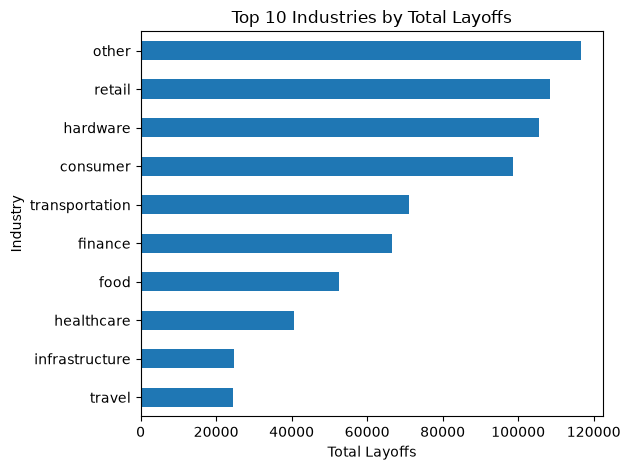

In [33]:
total_layoffs_by_industry.head(10).sort_values().plot(kind = 'barh')
plt.title('Top 10 Industries by Total Layoffs')
plt.xlabel('Total Layoffs')
plt.ylabel('Industry')
plt.tight_layout()
plt.savefig('Total_layoffs_by_Industries')
plt.show()

In [34]:
#total layoffs by month
df.groupby(df['date'].dt.to_period('M'))['total_laid_off'].sum().reset_index().head()

,date,total_laid_off
0,2020-03,9628.0
1,2020-04,26710.0
2,2020-05,25804.0
3,2020-06,7627.0
4,2020-07,7112.0


In [41]:
#total layoffs by country
total_layoffs_by_country = df.groupby("country")["total_laid_off"].sum().sort_values(ascending=False)
total_layoffs_by_country.reset_index().head(10)

,country,total_laid_off
0,united states,661313.0
1,india,67889.0
2,germany,32153.0
3,united kingdom,24694.0
4,netherlands,22175.0
5,sweden,20579.0
6,canada,16954.0
7,israel,15964.0
8,brazil,11939.0
9,china,8190.0


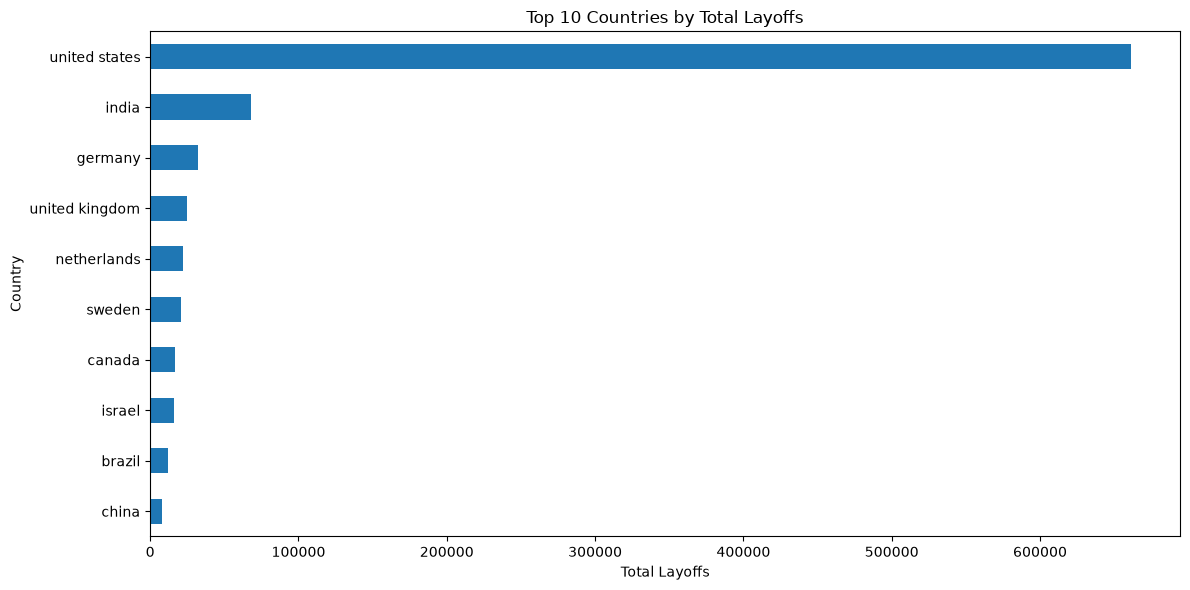

In [42]:
plt.figure(figsize=(12,6))
total_layoffs_by_country.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Countries by Total Layoffs')
plt.xlabel('Total Layoffs')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('Total_layoffs_by_Countries')
plt.show()

In [37]:
#Bonus Mystery
df[['company','total_laid_off','percentage_laid_off']].sort_values('percentage_laid_off',ascending = False).head(20)

,company,total_laid_off,percentage_laid_off
19,hale,NaN,1.0
20,orionx,NaN,1.0
4610,service,NaN,1.0
8,pulley,NaN,1.0
31,satvacart,NaN,1.0
982,joonko,NaN,1.0
987,karhoo,NaN,1.0
991,mainvest,NaN,1.0
1001,arkane studios,96.0,1.0
1002,brilliant,NaN,1.0


In [38]:
df[['company','total_laid_off','percentage_laid_off']].sort_values('total_laid_off',ascending = False).head(20)

,company,total_laid_off,percentage_laid_off
558,intel,22000.0,0.20
132,oracle,21000.0,0.13
320,amazon,16000.0,NaN
876,intel,15000.0,0.15
1043,tesla,14000.0,0.10
395,amazon,14000.0,0.01
2515,google,12000.0,0.06
271,dell,11000.0,0.10
3000,meta,11000.0,0.13
2189,meta,10000.0,NaN


In [39]:
high_percentage = df[(df['percentage_laid_off'] >= 0.8) &(df['total_laid_off'] <= 100)]
high_percentage.sort_values('total_laid_off', ascending=False).head(10)

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
1061,ghost autonomy,sf bay area,100.0,2024-04-03,1.00,transportation,https://www.sfgate.com/tech/article/ghost-auto...,series e,247.0,united states,2024-04-04
1092,phantom auto,sf bay area,100.0,2024-03-12,1.00,transportation,https://techcrunch.com/2024/03/12/remote-drivi...,unknown,86.0,united states,2024-03-12
2329,emx digital,new york city,100.0,2023-02-13,1.00,marketing,https://www.businessinsider.com/big-village-ba...,unknown,180.0,united states,2023-02-24
3784,udayy,"gurugram, non-u.s.",100.0,2022-06-01,1.00,education,https://www.moneycontrol.com/news/business/sta...,seed,2.0,india,2022-06-01
3206,kitty hawk,sf bay area,100.0,2022-09-21,1.00,aerospace,https://www.sfgate.com/bayarea/article/silicon...,unknown,1.0,united states,2022-09-22
3082,fifth season,pittsburgh,100.0,2022-10-28,1.00,food,https://www.bizjournals.com/pittsburgh/news/20...,series b,35.0,united states,2022-10-30
3159,pavilion data,sf bay area,96.0,2022-10-10,0.96,infrastructure,https://blocksandfiles.com/2022/10/10/pavilion...,series d,103.0,united states,2022-10-25
1001,arkane studios,austin,96.0,2024-05-08,1.00,consumer,https://www.bizjournals.com/austin/news/2024/0...,unknown,180.0,united states,2024-05-10
2002,scribe media,austin,90.0,2023-05-04,1.00,marketing,https://www.bizjournals.com/austin/inno/storie...,unknown,180.0,united states,2023-05-31
4079,scalefactor,austin,90.0,2020-06-23,0.90,finance,https://www.forbes.com/sites/davidjeans/2020/0...,series c,103.0,united states,2020-06-23


In [40]:
high_total = df[(df['total_laid_off'] >= 1000) &(df['percentage_laid_off'] <= 0.2)]
high_total[['company', 'total_laid_off', 'percentage_laid_off']]

,company,total_laid_off,percentage_laid_off
22,uber,3300.0,0.10
109,microsoft,4800.0,0.02
132,oracle,21000.0,0.13
135,lucid motors,1500.0,0.18
178,wix,1000.0,0.20
...,...,...,...
4142,uber,3000.0,0.13
4144,swiggy,1100.0,0.14
4171,stone,1300.0,0.20
4188,uber,3700.0,0.14


## Recommendations

1. **Confident finding:** Hardware, retail, and consumer led total layoffs even after removing duplicates and fixing the missing-value handling, so this ranking reflects real disclosed numbers, not fabricated ones.
2. **Caution needed:** ~850 rows are still missing `total_laid_off` and ~980 are missing `percentage_laid_off`, so every industry/country total is a floor, not the true total.
3. **Business takeaway:** Layoffs concentrated in capital-heavy, thin-margin sectors (hardware, retail, consumer) rather than "tech" broadly, so sector-level demand sensitivity matters more than the tech label itself.

## Bonus Mystery

Intel cut 22,000 people but that was only 20% of its workforce, while Ghost Autonomy cut just 100 people but that was 100% — the total tells you scale of market impact, the percentage tells you severity to the company, and leading with only one gives opposite impressions of the same kind of event.